Imports

In [10]:
import os
import json
import base64
import pandas as pd
from io import BytesIO
from dotenv import load_dotenv
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPImage
from pydantic import BaseModel, Field
from typing import List, Dict, Optional
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from google import genai
from google.genai import types
load_dotenv()
GOOGLE_API_KEY = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=GOOGLE_API_KEY)

Pydantic Output Schema

In [11]:
class ClassificationResponse(BaseModel):
    reasoning: str = Field(..., description="Step-by-step reasoning")
    classification: Dict[str, str] = Field(..., description="food_count + has_label")
    food_items: List[str] = Field(..., description="Cleaned list of food items")

class TaxonomyInfo(BaseModel):
    main_dish: str
    ingredients: List[str]
    categories: List[str]

In [12]:
def encode_image(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

Prompt classification

In [13]:
classification_prompt = """
You are an advanced food image understanding system optimized for real-world dietary analysis. Your task is to classify the **actual food consumed** in a photograph, focusing only on what’s clearly visible and contextually edible.

The goal is not just to name objects, but to deduce what the user most likely ate.

### Visual Inference Guidelines:

1. **Primary Food Identification**:
   - If a dish has multiple parts that clearly belong together (e.g., “burger with fries,” “ramen with egg and broth”), treat them as a **Single** item.
   - If the image contains distinct food types that are not served as a single dish (e.g., “sushi and chocolate cake”), classify as **Multiple**.
   - If unsure, default to **Single**, favoring cohesion over fragmentation.

2. **Foreground Priority**:
   - Only classify **clear, in-focus** food items in the foreground.
   - Disregard background clutter, blurry elements, and side items not central to the image.

3. **Non-Food Filtering**:
   - Do NOT include: plates, utensils, packaging, jars, napkins, tables, boxes, appliances.
   - Exception: If the food item is presented in a labeled container (e.g., Starbucks cup), you may retain that branding context.

4. **Labeling Rule**:
   - Use `"Labeled"` only if the **food itself** (or its immediate container) has a **clearly readable brand**.
   - Otherwise, default to `"Unlabeled"`.

5. **Food Item Naming**:
   - Use **natural, human-style** dish names: e.g., “egg sandwich,” “fruit bowl,” “coffee with cream.”
   - Do NOT split cohesive foods into parts (e.g., don’t say “egg, broth, noodles” — say “ramen with egg”).
   - Avoid artificial labels like “item1,” “foodA,” or overly technical names.

---

###  Output Format

Return **ONLY valid JSON**. No markdown, headers, or commentary.

```json
{
  "reasoning": "Explain step-by-step why you chose each food item (e.g., 'The image shows a bowl of noodles with visible broth and egg; these form a cohesive dish. No visible branding, so Unlabeled.')",
  "classification": {
    "food_count": "Single" or "Multiple",
    "has_label": "Labeled" or "Unlabeled"
  },
  "food_items": ["..."]
}

"""

def classify_food_image(base64_img):
    try:
        contents = [{
            "parts": [
                {"text": classification_prompt},
                {"inline_data": {"mime_type": "image/png", "data": base64_img}}
            ]
        }]
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=contents
        )
        response_text = response.text.strip("```json").strip("```").strip()
        parsed = json.loads(response_text)
        return ClassificationResponse(**parsed)
    except Exception as e:
        print("Classification error:", e)
        return None

Taxonomy prompt

In [14]:
taxonomy_prompt = """
Given this food description, decompose it into:
- main_dish
- ingredients
- food categories (e.g., grains, protein, vegetables)

Return valid JSON:
{
  "main_dish": "...",
  "ingredients": ["..."],
  "categories": ["..."]
}
"""

def get_taxonomy_from_text(food_text):
    try:
        contents = [{
            "parts": [{"text": f"{taxonomy_prompt}\n\nFood: {food_text}"}]
        }]
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=contents
        )
        response_text = response.text.strip("```json").strip("```").strip()
        parsed = json.loads(response_text)
        return TaxonomyInfo(**parsed)
    except Exception as e:
        print("Taxonomy error:", e)
        return None

Process Images

In [ ]:
from pathlib import Path
new_ground_truth_path = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/edge_case_2.json"
with open(new_ground_truth_path, "r") as f:
    new_ground_truth = {item["new_path"]: item["desc_text"] for item in json.load(f)}
image_folder = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/images"
new_image_files = [f"image_{i}.png" for i in range(100, 200)]
new_results = []

for file_name in tqdm(new_image_files, desc="Processing image_100–199"):
    image_path = os.path.join(image_folder, file_name)
    if not os.path.exists(image_path):
        print(f"Missing image file: {file_name}")
        continue

    base64_img = encode_image(image_path)

    classification = classify_food_image(base64_img)
    if not classification:
        print(f"Skipping {file_name} due to classification error.")
        continue

    combined_food_text = ", ".join(classification.food_items)

    taxonomy = get_taxonomy_from_text(combined_food_text)

    if taxonomy is None:
        taxonomy_data = {"main_dish": "Unknown", "ingredients": [], "categories": []}
    else:
        taxonomy_data = taxonomy.model_dump()
        if taxonomy_data.get("main_dish") is None:
            taxonomy_data["main_dish"] = "Unknown"
        if taxonomy_data.get("ingredients") is None:
            taxonomy_data["ingredients"] = []
        if taxonomy_data.get("categories") is None:
            taxonomy_data["categories"] = []

    new_results.append({
        "file_name": file_name,
        "food_count": classification.classification["food_count"],
        "has_label": classification.classification["has_label"],
        "food_items": classification.food_items,
        "reasoning": classification.reasoning,
        "taxonomy": taxonomy_data,
        "ground_truth_desc": new_ground_truth.get(file_name, "")
    })

output_path = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/classification_plus_taxonomy.json"
if Path(output_path).exists():
    with open(output_path, "r") as f:
        old_results = json.load(f)
else:
    old_results = []

# Combine and save
combined_results = old_results + new_results

with open(output_path, "w") as f:
    json.dump(combined_results, f, indent=4)

print(f"\n Successfully appended {len(new_results)} new entries to:")
print(f"→ {output_path}")
print(f" Total entries now: {len(combined_results)}")

Processing image_100–199:  41%|████      | 41/100 [01:29<02:19,  2.36s/it]

Taxonomy error: Expecting value: line 1 column 1 (char 0)


Processing image_100–199:  45%|████▌     | 45/100 [01:38<02:04,  2.26s/it]

Taxonomy error: Expecting value: line 1 column 1 (char 0)


Processing image_100–199:  77%|███████▋  | 77/100 [02:47<00:50,  2.17s/it]

...

Taxonomy error: Expecting value: line 1 column 1 (char 0)


Processing image_100–199:  80%|████████  | 80/100 [02:53<00:41,  2.07s/it]

Taxonomy error: Extra data: line 6 column 1 (char 235)


Processing image_100–199: 100%|██████████| 100/100 [03:43<00:00,  2.24s/it]


✅ Successfully appended 100 new entries to:
→ /Users/tanishqsingh/Documents/GitHub/yolovfaces/classification_plus_taxonomy.json
📊 Total entries now: 200


Embedding and Cosine 

In [ ]:
import json
import time
import random
import numpy as np
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
with open("/Users/tanishqsingh/Documents/GitHub/yolovfaces/edge_case_1_clean.json", "r") as f:
    user_desc_0_99 = {f"image_{item['Sno'] - 1}.png": item["desc_text"] for item in json.load(f)}
with open("/Users/tanishqsingh/Documents/GitHub/yolovfaces/edge_case_2.json", "r") as f:
    user_desc_100_199 = {item["new_path"]: item["desc_text"] for item in json.load(f)}
full_user_desc = {**user_desc_0_99, **user_desc_100_199}
input_path = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/classification_plus_taxonomy.json"
with open(input_path, "r") as f:
    results = json.load(f)
def get_embedding_with_backoff(text, max_retries=8, base_delay=3.0):
    for attempt in range(max_retries):
        try:
            result = client.models.embed_content(
                model="gemini-embedding-exp-03-07",
                contents=text,
                config=types.EmbedContentConfig(task_type="SEMANTIC_SIMILARITY")
            )
            return np.array(result.embeddings[0].values)
        except Exception as e:
            wait_time = base_delay * (2 ** attempt) + random.uniform(0.5, 2.0)
            print(f" Attempt {attempt + 1} failed: {e}")
            print(f" Retrying in {wait_time:.2f} seconds...")
            time.sleep(wait_time)
    print(f" Failed after {max_retries} retries: {text[:60]}...")
    return None
for r in tqdm(results, desc="Computing semantic similarity for 0–199"):
    file_name = r["file_name"]
    gemini_text = ", ".join(r.get("food_items", []))
    user_desc = full_user_desc.get(file_name, "")

    r["ground_truth_desc"] = user_desc

    emb1 = get_embedding_with_backoff(gemini_text)
    emb2 = get_embedding_with_backoff(user_desc)

    if emb1 is not None and emb2 is not None:
        sim_score = cosine_similarity([emb1], [emb2])[0][0]
        r["semantic_similarity"] = round(float(sim_score), 4)
    else:
        r["semantic_similarity"] = None
        print(f" Could not compute similarity for {file_name}")
output_path = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/classification_with_similarity.json"
with open(output_path, "w") as f:
    json.dump(results, f, indent=4)
print(f"\n Saved to: {output_path}")
print(f" Total entries processed: {len(results)}")
print("Last few file names:", [r["file_name"] for r in results[-3:]])

Computing semantic similarity for 0–199:  12%|█▎        | 25/200 [00:32<03:47,  1.30s/it]

 Attempt 1 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 4.79 seconds...
 Attempt 2 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 6.59 seconds...


Computing semantic similarity for 0–199:  13%|█▎        | 26/200 [00:45<14:00,  4.83s/it]

 Attempt 1 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 4.68 seconds...
 Attempt 2 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 7.90 seconds...
 Attempt 1 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 3.65 seconds...


Computing semantic similarity for 0–199:  26%|██▌       | 52/200 [01:41<03:04,  1.25s/it]

...

 Attempt 1 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 4.56 seconds...


Computing semantic similarity for 0–199:  89%|████████▉ | 178/200 [06:41<00:30,  1.40s/it]

 Attempt 1 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 3.78 seconds...
 Attempt 2 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 7.68 seconds...
 Attempt 3 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}}
 Retrying in 12.67 seconds...


Computing semantic similarity for 0–199: 100%|██████████| 200/200 [07:37<00:00,  2.29s/it]


 Saved to: /Users/tanishqsingh/Documents/GitHub/yolovfaces/classification_with_similarity.json
 Total entries processed: 200
Last few file names: ['image_197.png', 'image_198.png', 'image_199.png']


Category-Wise Similarity Analysis

In [22]:
from collections import defaultdict
from statistics import mean

category_scores = defaultdict(list)
for r in results:
    if r.get("semantic_similarity") is not None:
        categories = r.get("taxonomy", {}).get("categories", [])
        if categories:
            category = categories[0]
        else:
            category = "Unknown"
        category_scores[category].append(r["semantic_similarity"])

for cat, sims in category_scores.items():
    print(f"{cat:<15} → Mean similarity: {mean(sims):.3f} (n={len(sims)})")

snacks          → Mean similarity: 0.930 (n=1)
soup            → Mean similarity: 0.908 (n=4)
beverages       → Mean similarity: 0.927 (n=11)
dessert         → Mean similarity: 0.930 (n=12)
beverage        → Mean similarity: 0.900 (n=13)
fruit           → Mean similarity: 0.933 (n=18)
protein         → Mean similarity: 0.896 (n=9)
Beverage        → Mean similarity: 0.898 (n=17)
salad           → Mean similarity: 0.905 (n=1)
Pizza           → Mean similarity: 0.957 (n=1)
Vegetables      → Mean similarity: 0.812 (n=1)
vegetables      → Mean similarity: 0.901 (n=17)
grain           → Mean similarity: 0.940 (n=3)
Unknown         → Mean similarity: 0.869 (n=16)
confectionery   → Mean similarity: 0.863 (n=1)
dairy           → Mean similarity: 0.900 (n=7)
baked goods     → Mean similarity: 0.894 (n=8)
meat            → Mean similarity: 0.900 (n=2)
grains          → Mean similarity: 0.893 (n=17)
Grains          → Mean similarity: 0.866 (n=5)
vegetable       → Mean similarity: 0.895 (n=1)
snack

Better ground truth csv

In [ ]:
import pandas as pd
import json
import os
import time
import random
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
truth_path_1 = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/Truthsetimages.csv"
truth_df_1 = pd.read_csv(truth_path_1)
truth_df_1.rename(columns={"Image": "file_name", "food item": "your_guess"}, inplace=True)

truth_path_2 = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/Truthset2.csv"
truth_df_2 = pd.read_csv(truth_path_2)
truth_df_2["file_name"] = truth_df_2["S.no"].apply(lambda x: f"image_{x}.png")
truth_df_2 = truth_df_2[["file_name", "your_guess"]]
truth_df = pd.concat([truth_df_1[["file_name", "your_guess"]], truth_df_2], ignore_index=True)
user_desc_path = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/edge_case_1_clean.json"
with open(user_desc_path, "r") as f:
    user_desc_raw = json.load(f)
user_desc_map = {f"image_{item['Sno'] - 1}.png": item["desc_text"] for item in user_desc_raw}
gemini_output_path = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/classification_with_similarity.json"
with open(gemini_output_path, "r") as f:
    gemini_data = json.load(f)
gemini_df = pd.DataFrame(gemini_data)
def get_embedding_with_backoff(text, max_retries=5, base_delay=2):
    for attempt in range(max_retries):
        try:
            result = client.models.embed_content(
                model="gemini-embedding-exp-03-07",
                contents=text,
                config=types.EmbedContentConfig(task_type="SEMANTIC_SIMILARITY")
            )
            return np.array(result.embeddings[0].values)
        except Exception as e:
            wait_time = base_delay * (2 ** attempt) + random.uniform(0.1, 0.3)
            print(f"Retrying after error: {e} → wait {wait_time:.2f}s")
            time.sleep(wait_time)
    return None
for r in gemini_data:
    gem_text = ", ".join(r.get("food_items", []))
    file_name = r["file_name"]

    your_guess = truth_df.loc[truth_df["file_name"] == file_name, "your_guess"].values[0] \
        if file_name in truth_df["file_name"].values else ""
    user_desc = user_desc_map.get(file_name, "")

    emb_gem = get_embedding_with_backoff(gem_text)
    emb_your = get_embedding_with_backoff(your_guess)
    emb_user = get_embedding_with_backoff(user_desc)

    r["similarity_gemini_vs_your_guess"] = (
        round(float(cosine_similarity([emb_gem], [emb_your])[0][0]), 4)
        if emb_gem is not None and emb_your is not None else None
    )
    r["similarity_gemini_vs_user_description"] = (
        round(float(cosine_similarity([emb_gem], [emb_user])[0][0]), 4)
        if emb_gem is not None and emb_user is not None else None
    )
final_df = pd.DataFrame()
final_df["file_name"] = gemini_df["file_name"]
final_df["image_path"] = final_df["file_name"].apply(lambda x: f"/images/{x}")
final_df["gemini_guess"] = gemini_df["food_items"].apply(lambda x: ", ".join(x) if isinstance(x, list) else "")
final_df["your_guess"] = final_df["file_name"].map(dict(zip(truth_df["file_name"], truth_df["your_guess"])))
final_df["user_description"] = final_df["file_name"].map(user_desc_map)  # Only 0–99 will have this
final_df["semantic_similarity"] = gemini_df["semantic_similarity"]
final_df["similarity_gemini_vs_your_guess"] = [r["similarity_gemini_vs_your_guess"] for r in gemini_data]
final_df["similarity_gemini_vs_user_description"] = [r["similarity_gemini_vs_user_description"] for r in gemini_data]
final_df["taxonomy_gemini_main"] = gemini_df["taxonomy"].apply(lambda x: x.get("main_dish", "") if isinstance(x, dict) else "")
final_df["taxonomy_gemini_ingredients"] = gemini_df["taxonomy"].apply(
    lambda x: ", ".join(x.get("ingredients", [])) if isinstance(x, dict) else "")
final_df["taxonomy_gemini_categories"] = gemini_df["taxonomy"].apply(
    lambda x: ", ".join(x.get("categories", [])) if isinstance(x, dict) else "")
final_df.drop(columns=["semantic_similarity"], inplace=True)
today = pd.Timestamp.today().strftime("%Y_%m_%d")
output_path = f"/Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_{today}.csv"
final_df.to_csv(output_path, index=False)
print(f" Ground truth CSV saved to: {output_path}")

Retrying after error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}} → wait 2.21s
Retrying after error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}} → wait 4.12s
Retrying after error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}} → wait 8.18s
Retrying after error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}} → wait 2.17s
Retrying after error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted (e.g. check quota).', 'status': 'RESOURCE_EXHAUSTED'}} → wait 4.25s
Retrying after error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Resource has been exhausted 

In [ ]:
with open("/Users/tanishqsingh/Documents/GitHub/yolovfaces/edge_case_2.json", "r") as f:
    user_desc_raw_2 = json.load(f)
user_desc_map_100_199 = {item["new_path"]: item["desc_text"] for item in user_desc_raw_2}
final_df["user_description"] = final_df.apply(
    lambda row: row["user_description"] if pd.notna(row["user_description"]) and row["user_description"].strip() != "" 
    else user_desc_map_100_199.get(row["file_name"], ""),
    axis=1
)

print(" Patched user_description for image_100–199")
today = pd.Timestamp.today().strftime("%Y_%m_%d")
patched_path = f"/Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_{today}_patched.csv"
final_df.to_csv(patched_path, index=False)
print(f" Saved updated CSV with full user descriptions to:\n{patched_path}")

✅ Patched user_description for image_100–199
 Saved updated CSV with full user descriptions to:
/Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_2025_04_23_patched.csv


ADDING THE USDA CLASSIFICATIONS

In [ ]:
USDA_MAIN_CLASSES = [
    "Milk and Dairy", "Protein Foods", "Mixed Dishes", "Grains",
    "Snacks and Sweets", "Fruit", "Vegetables", "Beverages",
    "Alcoholic Beverages", "Fats and Oils", "Condiments and Sauces",
    "Sugars", "Baby Foods and Formulas", "Other"
]

USDA_SUBCLASSES = {
    "Milk and Dairy": ["Milk", "Flavored Milk", "Dairy Drinks", "Cheese", "Yogurt", "Plant-based Dairy"],
    "Protein Foods": ["Meats", "Poultry", "Seafood", "Eggs", "Cured Meats/Poultry", "Plant-based Protein Foods"],
    "Mixed Dishes": [
        "Mixed Dishes - Meat, Poultry, Seafood", "Mixed Dishes - Bean/Vegetable-based",
        "Mixed Dishes - Grain-based", "Mixed Dishes - Asian", "Mixed Dishes - Mexican",
        "Mixed Dishes - Pizza", "Mixed Dishes - Sandwiches", "Mixed Dishes - Soups"
    ],
    "Grains": ["Cooked Grains", "Breads, Rolls, Tortillas", "Quick Breads and Bread Products", "Ready-to-Eat Cereals", "Cooked Cereals"],
    "Snacks and Sweets": ["Savory Snacks", "Crackers", "Snack/Meal Bars", "Sweet Bakery Products", "Candy", "Other Desserts"],
    "Fruit": ["Fruits"], "Vegetables": ["Vegetables, excluding potatoes", "White Potatoes"],
    "Beverages": ["100% Juice", "Diet Beverages", "Sweetened Beverages", "Coffee and Tea"],
    "Alcoholic Beverages": ["Alcoholic Beverages"], "Fats and Oils": ["Fats and Oils"],
    "Condiments and Sauces": ["Condiments and Sauces"], "Sugars": ["Sugars"],
    "Baby Foods and Formulas": ["Baby Foods", "Baby Beverages", "Infant Formulas", "Human Milk"],
    "Other": ["Other"]
}
def classify_main_usda_category(food_name):
    prompt = f"""
You are a food classification assistant. Your task is to assign the most appropriate USDA main food category to a given food name.

Choose from the following USDA main categories:
{chr(10).join(f"- {cat}" for cat in USDA_MAIN_CLASSES)}

Food name: "{food_name}"

Respond with only the name of the category from the list above.
"""
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash", contents=prompt, config={"temperature": 0.0}
        )
        result = response.text.strip()
        return result if result in USDA_MAIN_CLASSES else "Other"
    except:
        return "Other"
def classify_sub_usda_category(food_name, main_category):
    subclass_list = USDA_SUBCLASSES.get(main_category, [])
    prompt = f"""
You are a food classification assistant. The USDA main category for the following food is "{main_category}".

Your task is to assign the most appropriate subclass from the list below:
{chr(10).join(f"- {s}" for s in subclass_list)}

Food name: "{food_name}"

Respond with only the name of the subclass from the list above.
"""
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash", contents=prompt, config={"temperature": 0.0}
        )
        result = response.text.strip()
        return result if result in subclass_list else "Other"
    except:
        return "Other"

In [26]:
final_df["usda_main_gemini"] = final_df["gemini_guess"].apply(classify_main_usda_category)
final_df["usda_sub_gemini"] = final_df.apply(
    lambda row: classify_sub_usda_category(row["gemini_guess"], row["usda_main_gemini"]), axis=1
)
final_df["usda_main_manual"] = final_df["your_guess"].apply(classify_main_usda_category)
final_df["usda_sub_manual"] = final_df.apply(
    lambda row: classify_sub_usda_category(row["your_guess"], row["usda_main_manual"]), axis=1
)

In [27]:
output_path = f"/Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_{today}.csv"
final_df.to_csv(output_path, index=False)
print(f"Ground truth CSV saved to: {output_path}")

Ground truth CSV saved to: /Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_2025_04_23.csv


USDA-Filtered Cosine Similarity Visualization

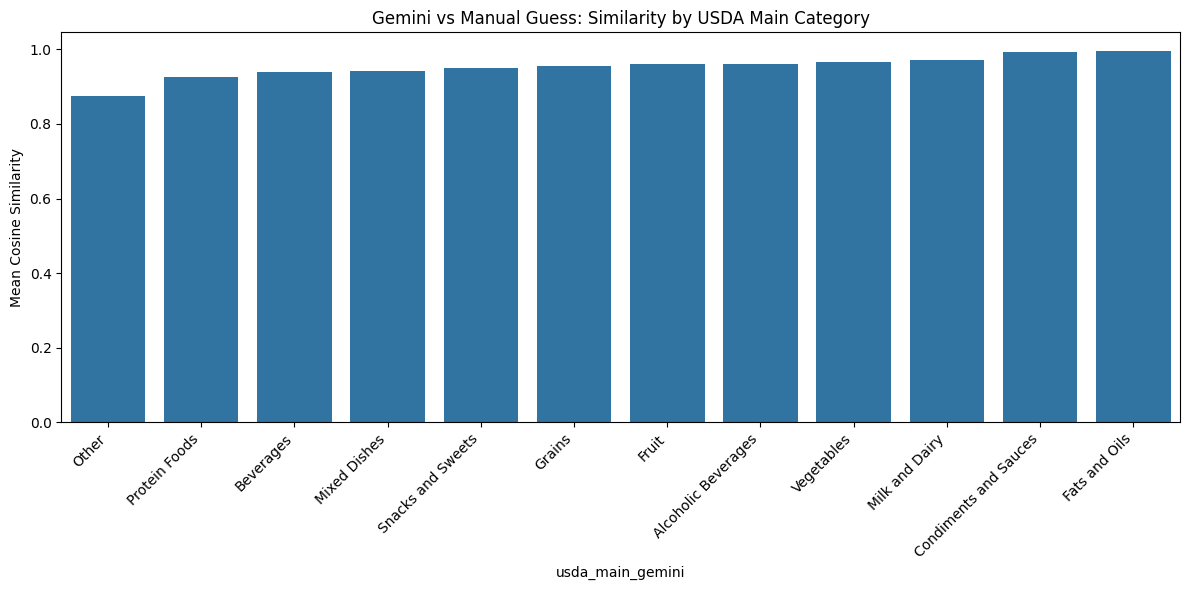

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df_plot = final_df.groupby("usda_main_gemini")["similarity_gemini_vs_your_guess"].agg(["mean", "count"]).reset_index()
df_plot = df_plot.sort_values("mean")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x="usda_main_gemini", y="mean")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Cosine Similarity")
plt.title("Gemini vs Manual Guess: Similarity by USDA Main Category")
plt.tight_layout()
plt.show()

Category count wise 

In [29]:
main_cat_gemini = final_df["usda_main_gemini"].value_counts().reset_index()
main_cat_gemini.columns = ["USDA Main Category (Gemini)", "Count"]
print("\n USDA Main Category Count (Gemini Guess):")
display(main_cat_gemini)
main_cat_manual = final_df["usda_main_manual"].value_counts().reset_index()
main_cat_manual.columns = ["USDA Main Category (Manual Guess)", "Count"]
print("\n USDA Main Category Count (Your Guess):")
display(main_cat_manual)
sub_cat_gemini = final_df["usda_sub_gemini"].value_counts().reset_index()
sub_cat_gemini.columns = ["USDA Subcategory (Gemini)", "Count"]
print("\n USDA Subcategory Count (Gemini Guess):")
display(sub_cat_gemini)
sub_cat_manual = final_df["usda_sub_manual"].value_counts().reset_index()
sub_cat_manual.columns = ["USDA Subcategory (Manual Guess)", "Count"]
print("\n USDA Subcategory Count (Your Guess):")
display(sub_cat_manual)


 USDA Main Category Count (Gemini Guess):


,USDA Main Category (Gemini),Count
0,Mixed Dishes,74
1,Beverages,41
2,Snacks and Sweets,24
3,Fruit,18
4,Grains,11
5,Other,10
6,Milk and Dairy,7
7,Protein Foods,4
8,Alcoholic Beverages,4
9,Vegetables,4



 USDA Main Category Count (Your Guess):


,USDA Main Category (Manual Guess),Count
0,Mixed Dishes,71
1,Beverages,40
2,Snacks and Sweets,25
3,Fruit,15
4,Grains,14
5,Milk and Dairy,9
6,Other,7
7,Vegetables,6
8,Alcoholic Beverages,5
9,Protein Foods,4



 USDA Subcategory Count (Gemini Guess):


,USDA Subcategory (Gemini),Count
0,Coffee and Tea,26
1,Fruits,18
2,Other,18
3,Mixed Dishes - Bean/Vegetable-based,17
4,"Mixed Dishes - Meat, Poultry, Seafood",13
5,Sweetened Beverages,11
6,Sweet Bakery Products,10
7,Mixed Dishes - Sandwiches,9
8,Mixed Dishes - Grain-based,7
9,Mixed Dishes - Soups,6



 USDA Subcategory Count (Your Guess):


,USDA Subcategory (Manual Guess),Count
0,Coffee and Tea,26
1,Mixed Dishes - Bean/Vegetable-based,18
2,"Mixed Dishes - Meat, Poultry, Seafood",17
3,Other,15
4,Fruits,15
5,Sweet Bakery Products,9
6,Sweetened Beverages,9
7,Candy,8
8,Mixed Dishes - Grain-based,7
9,"Vegetables, excluding potatoes",6


In [ ]:
main_counts_gemini = final_df["usda_main_gemini"].value_counts()
main_counts_manual = final_df["usda_main_manual"].value_counts()
sub_counts_gemini = final_df["usda_sub_gemini"].value_counts()
sub_counts_manual = final_df["usda_sub_manual"].value_counts()
main_df = pd.DataFrame({
    "Category": main_counts_gemini.index,
    "Gemini Count": main_counts_gemini.values,
    "Manual Count": main_counts_manual.reindex(main_counts_gemini.index).fillna(0).astype(int)
})

sub_df = pd.DataFrame({
    "Subcategory": sub_counts_gemini.index,
    "Gemini Count": sub_counts_gemini.values,
    "Manual Count": sub_counts_manual.reindex(sub_counts_gemini.index).fillna(0).astype(int)
})

main_df.to_csv("usda_main_category_counts.csv", index=False)
sub_df.to_csv("usda_sub_category_counts.csv", index=False)
print("\nExported USDA category counts to:")
print("- usda_main_category_counts.csv")
print("- usda_sub_category_counts.csv")


Exported USDA category counts to:
- usda_main_category_counts.csv
- usda_sub_category_counts.csv


USDA Main Category comparision between manual and gemini 

In [31]:
final_df["usda_main_agreement"] = final_df["usda_main_gemini"] == final_df["usda_main_manual"]
agreement_ratio = final_df["usda_main_agreement"].mean()
print(f" USDA main category agreement rate: {agreement_ratio*100:.1f}%")
today = pd.Timestamp.today().strftime("%Y_%m_%d")
final_df.to_csv(f"/Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_enriched_{today}.csv", index=False)

 USDA main category agreement rate: 85.0%


Visualizations

Distribution of Similarity by Category

/var/folders/k7/mmnyfjh16vj74m2rfzds86pr0000gn/T/ipykernel_60884/2815559349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_df, x="usda_main_gemini", y="similarity_gemini_vs_your_guess", palette="Set3")


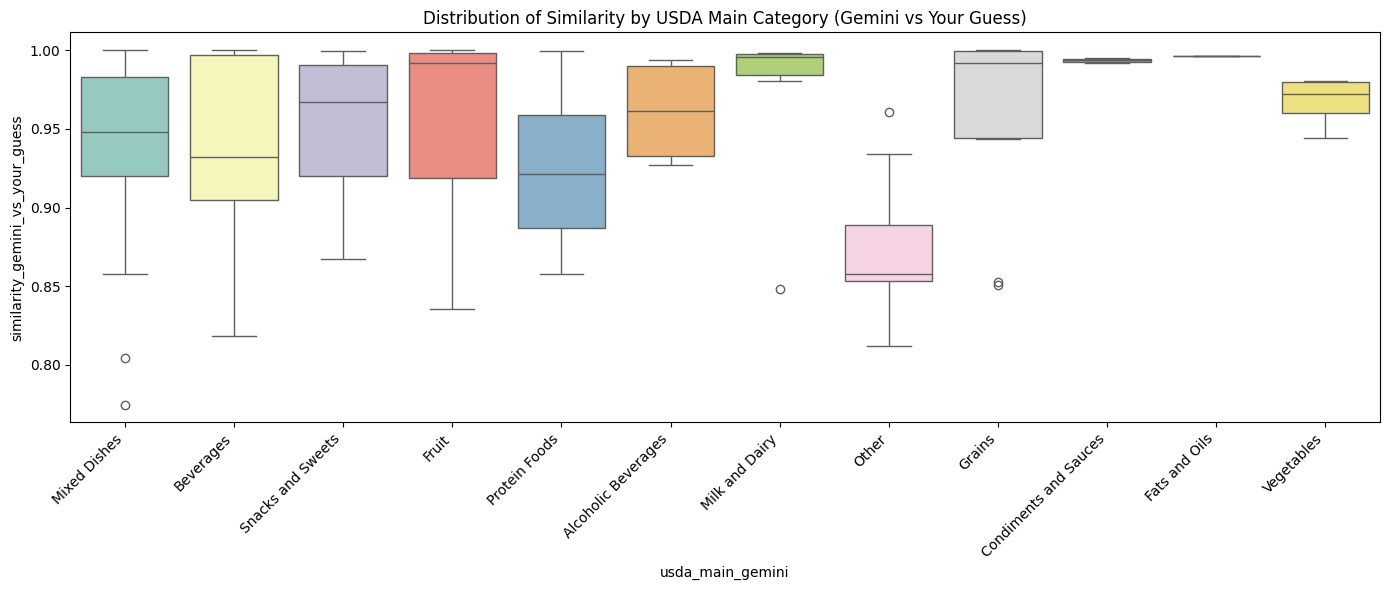

In [32]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=final_df, x="usda_main_gemini", y="similarity_gemini_vs_your_guess", palette="Set3")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Similarity by USDA Main Category (Gemini vs Your Guess)")
plt.tight_layout()
plt.show()

Highlight Worst Performing Categories in a Table

In [33]:
summary_table = final_df.groupby("usda_main_gemini")["similarity_gemini_vs_your_guess"].agg(["mean", "count"]).reset_index()
summary_table = summary_table.sort_values("mean")
print(" USDA Categories Where Gemini Struggles the Most:")
display(summary_table.head(5))

 USDA Categories Where Gemini Struggles the Most:


,usda_main_gemini,mean,count
8,Other,0.874190,10
9,Protein Foods,0.924850,4
1,Beverages,0.940610,41
7,Mixed Dishes,0.943281,74
10,Snacks and Sweets,0.951029,24


Per-Image Errors Below Threshold of 0.9

In [34]:
low_sim_df = final_df[final_df["similarity_gemini_vs_your_guess"] < 0.9][
    ["file_name", "gemini_guess", "your_guess", "similarity_gemini_vs_your_guess", "usda_main_gemini"]
].sort_values("similarity_gemini_vs_your_guess")
print(f"Found {len(low_sim_df)} Gemini guesses with similarity < 0.9:")
display(low_sim_df.head(10))

Found 40 Gemini guesses with similarity < 0.9:


,file_name,gemini_guess,your_guess,similarity_gemini_vs_your_guess,usda_main_gemini
188,image_188.png,Pasta dish,Empty,0.7749,Mixed Dishes
53,image_53.png,"burger, salad",Club Soda,0.8044,Mixed Dishes
36,image_36.png,gelatin,Mango Juice,0.8119,Other
111,image_111.png,Drink with powder,Chicory,0.8182,Beverages
175,image_175.png,peach,Cheese,0.8358,Fruit
150,image_150.png,ice cream,Muesli,0.8480,Milk and Dairy
107,image_107.png,Unidentifiable food item,egg,0.8489,Other
186,image_186.png,Porridge,halwa,0.8507,Grains
143,image_143.png,scones,Pumpkin coffee cake,0.8527,Grains
144,image_144.png,,nothing,0.8533,Other


Low Performance(Less than 0.9) Pie Chart

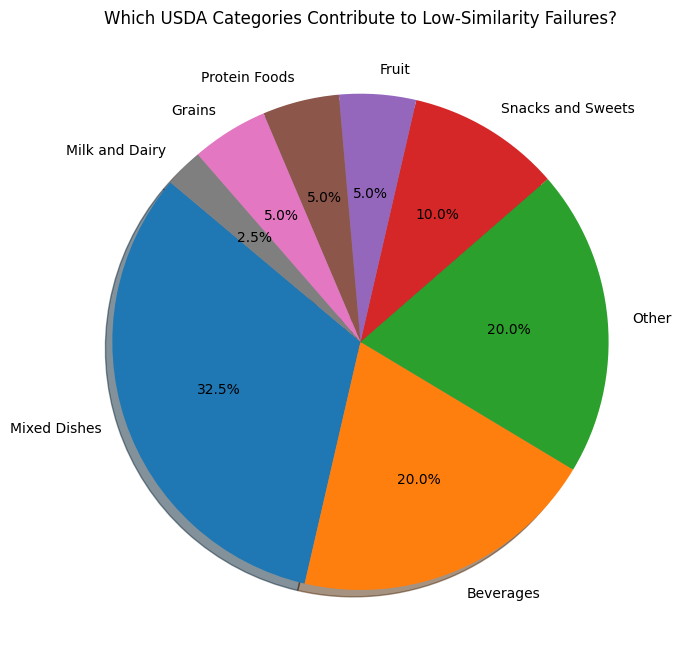

In [35]:
low_sim_pie = final_df[final_df["similarity_gemini_vs_your_guess"] < 0.9]["usda_main_gemini"].value_counts()
plt.figure(figsize=(7, 7))
low_sim_pie.plot.pie(autopct="%1.1f%%", shadow=True, startangle=140)
plt.title("Which USDA Categories Contribute to Low-Similarity Failures?")
plt.ylabel("")
plt.tight_layout()
plt.show()

trying to find nutrition facts

In [ ]:
from fuzzywuzzy import fuzz
import pandas as pd
import requests
import time
from tqdm import tqdm
df = pd.read_csv("/Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_enriched_2025_04_23.csv")
USDA_API_KEY = ""
def fetch_best_nutrition(food_name, retries=3):
    search_url = "https://api.nal.usda.gov/fdc/v1/foods/search"
    params = {
        "api_key": USDA_API_KEY,
        "query": food_name,
        "dataType": "Foundation,SR Legacy,FNDDS,Branded",
        "pageSize": 50
    }

    for _ in range(retries):
        try:
            response = requests.get(search_url, params=params)
            if response.status_code == 200:
                data = response.json()
                foods = data.get("foods", [])
                if not foods:
                    return {}
                best_match = max(
                    foods,
                    key=lambda f: fuzz.token_sort_ratio(food_name.lower(), f["description"].lower())
                )
                score = fuzz.token_sort_ratio(food_name.lower(), best_match["description"].lower())
                nutrients = {n["nutrientName"]: n["value"] for n in best_match.get("foodNutrients", [])}

                return {
                    "Calories": nutrients.get("Energy"),
                    "Protein": nutrients.get("Protein"),
                    "TotalFat": nutrients.get("Total lipid (fat)"),
                    "Carbs": nutrients.get("Carbohydrate, by difference"),
                    "ServingSize": best_match.get("servingSize"),
                    "ServingUnit": best_match.get("servingSizeUnit"),
                    "Brand": best_match.get("brandOwner", ""),
                    "DataType": best_match.get("dataType", ""),
                    "Description": best_match.get("description", ""),
                    "FDC_ID": best_match.get("fdcId"),
                    "MatchConfidence": score
                }
            time.sleep(1.5)
        except Exception as e:
            print(f"Error: {e} → retrying...")
            time.sleep(2)
    return {}
nutrition_cache = {}
unique_foods = df["gemini_guess"].dropna().unique()

print(f" Fetching USDA matches for {len(unique_foods)} Gemini guesses...")
for food in tqdm(unique_foods):
    nutrition_cache[food] = fetch_best_nutrition(food)
df["Calories"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("Calories"))
df["Protein_g"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("Protein"))
df["Fat_g"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("TotalFat"))
df["Carbs_g"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("Carbs"))
df["ServingSize"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("ServingSize"))
df["ServingUnit"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("ServingUnit"))
df["Brand"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("Brand"))
df["DataType"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("DataType"))
df["Description"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("Description"))
df["FDC_ID"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("FDC_ID"))
df["MatchConfidence"] = df["gemini_guess"].map(lambda x: nutrition_cache.get(x, {}).get("MatchConfidence"))
out_path = "/Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_enriched_with_nutrition.csv"
df.to_csv(out_path, index=False)
print(f"\n Nutrition columns added and saved to:\n{out_path}")

🔍 Fetching USDA matches for 176 Gemini guesses...


100%|██████████| 176/176 [02:25<00:00,  1.21it/s]


 Nutrition columns added and saved to:
/Users/tanishqsingh/Documents/GitHub/yolovfaces/ground_truth_enriched_with_nutrition.csv
